Verify the Google Colab kernel is active

In [1]:
# I am using Google Colab GPUs and TPUs in Visual Studio Code
import sys
if 'google.colab' in sys.modules:
    print('✅I am in Google Colab')
    print(f'Python version: {sys.version}')
else:
    print('❌Not in Google Colab')

✅I am in Google Colab
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Check hardware available

In [2]:
# Check Hardware specifications
import psutil
import os

# RAM
ram_gb = psutil.virtual_memory().total / (1024**3)
print(f"💾 RAM total: {ram_gb:.2f} GB")

# CPU
cpu_count = psutil.cpu_count()
print(f"⚙️ CPUs disponibles: {cpu_count}")

# Verificar GPU
gpu_info = !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null
if gpu_info:
    print(f"🎮 GPU: {gpu_info[0]}")
else:
    print("⚠️ No hay GPU disponible (usando CPU)")

🎮 GPU: Tesla T4, 15360 MiB


Download the only library needed that is not already on the Google Colab python env

In [ ]:
#Only used for Bayesian Hyperparameter Optimization
%pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.1 MB/s eta 0:00:00


Download (or load if has already been downloaded) a TF dataset with Rock, Paper and Scissors images

In [1]:
import tensorflow_datasets as tfds
ds, info = tfds.load('rock_paper_scissors', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.NRO1IA_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.NRO1IA_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


Visualise the image nº N of the train split

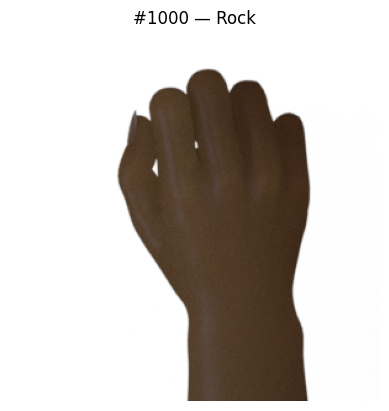

In [4]:
import matplotlib.pyplot as plt
N = 1000
ds_train = ds['train']  # extraer el split
LABELS = ['Rock', 'Paper', 'Scissors']

image, label = next(iter(ds_train.skip(N).take(1)))
plt.imshow(image.numpy())
plt.title(f'#{N} — {LABELS[label.numpy()]}')
plt.axis('off')
plt.show()


CNN Model — Baseline

Mounted at /content/drive


Model saved


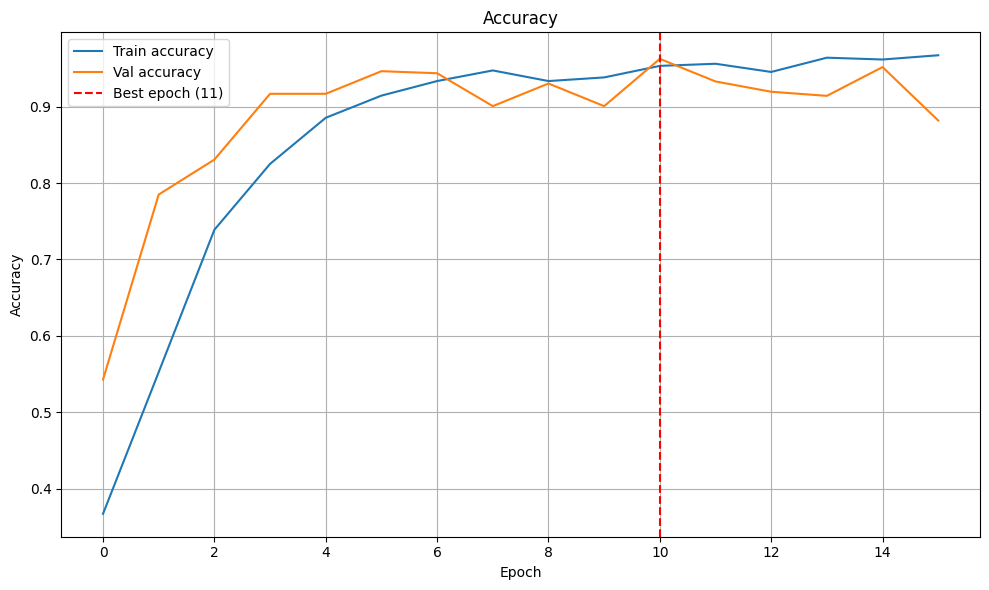

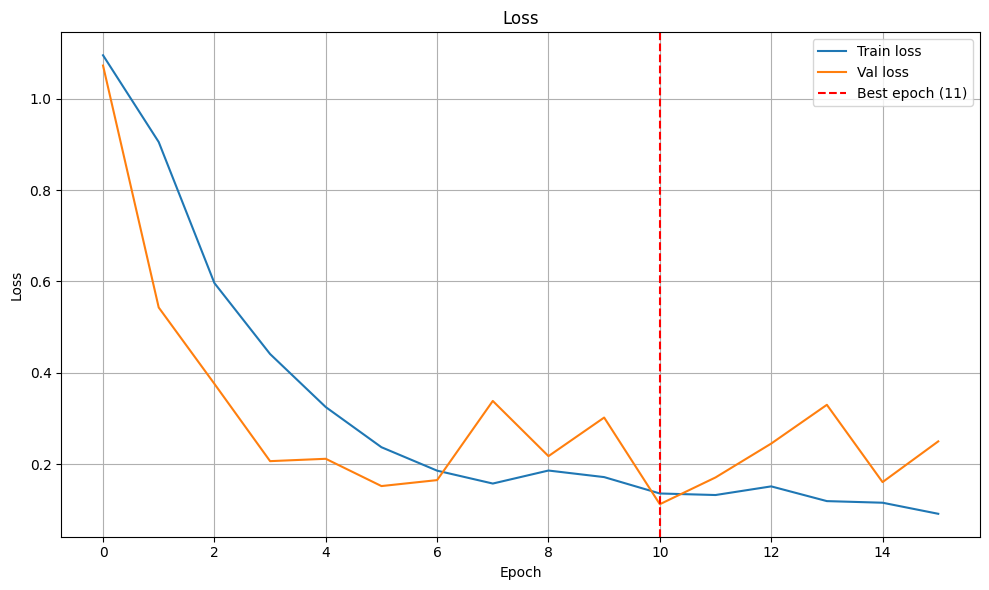

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# ── Load & preprocess ──────────────────────────────────────────────
IMG_SIZE = (64, 64)
BATCH    = 32
EPOCHS   = 200

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label
def plot_history(history, early_stopping):
    stopped_epoch = early_stopping.stopped_epoch
    best_epoch = stopped_epoch - early_stopping.patience if stopped_epoch > 0 else None

    # ── Accuracy ───────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'],     label='Train accuracy')
    plt.plot(history.history['val_accuracy'], label='Val accuracy')
    if best_epoch:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ── Loss ───────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['val_loss'], label='Val loss')
    if best_epoch:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

ds = tfds.load('rock_paper_scissors', as_supervised=True)
train_ds = (ds['train']
            .map(preprocess)
            .shuffle(1000)
            .map(augment)
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))
test_ds  = (ds['test']
            .map(preprocess)
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))

# ── Build CNN ──────────────────────────────────────────────────────
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    #DATA AUGMENTATION
    layers.RandomFlip('horizontal'),               # left-to-right
    layers.RandomFlip('vertical'),                 # top-to-bottom
    layers.RandomRotation(factor=0.20),            # ±20% of 2π
    layers.RandomContrast(factor=0.5),             # contrast range [1-0.5, 1+0.5]
    layers.RandomTranslation(
        height_factor=0.1,                         # shift up/down 10%
        width_factor=0.1                           # shift left/right 10%
    ),
    # ── Conv Block 1 ───────────────────────────────────────────────
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    # ── Conv Block 2 ───────────────────────────────────────────────
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    # ── Conv Block 3 ───────────────────────────────────────────────
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    # ── Head ───────────────────────────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ── Train & save ───────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=[early_stopping]
)
#model.save('rps_model.keras') #Save local if not using google colab
#model.save('rps_model.h5') #Save local if not using google colab

from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/MyDrive/rps_model_128.keras') #Save in Google Drive if using Colab
model.save('/content/drive/MyDrive/rps_model_128.h5') #Save in Google Drive if using Colab

print("Model saved")

# ── Plot training vs validation ────────────────────────────────────
plot_history(history, early_stopping)

In [25]:
model.save('/content/drive/MyDrive/rps_model_simple.keras') #Save in Google Drive if using Colab

CNN Model — Bayesian Hyperparameter Optimization

Trial 10 Complete [00h 01m 02s]
val_accuracy: 0.9543010592460632

Best val_accuracy So Far: 0.9596773982048035
Total elapsed time: 00h 07m 53s
Results summary
Results in kt_results/rps_bayes_v2
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 08 summary
Hyperparameters:
num_conv_blocks: 3
filters_0: 256
dense_units: 128
dropout: 0.5
learning_rate: 0.0001
filters_1: 32
filters_2: 32
filters_3: 256
Score: 0.9596773982048035

Trial 09 summary
Hyperparameters:
num_conv_blocks: 4
filters_0: 256
dense_units: 256
dropout: 0.6000000000000001
learning_rate: 0.0001
filters_1: 64
filters_2: 32
filters_3: 128
Score: 0.9543010592460632

Trial 04 summary
Hyperparameters:
num_conv_blocks: 3
filters_0: 256
dense_units: 64
dropout: 0.5
learning_rate: 0.0001
filters_1: 128
filters_2: 32
filters_3: 256
Score: 0.9247311949729919

Trial 05 summary
Hyperparameters:
num_conv_blocks: 2
filters_0: 256
dense_units: 128
dropout: 0.5
learning_rate: 0.0001
filters_1: 128
filters_2: 32


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved!


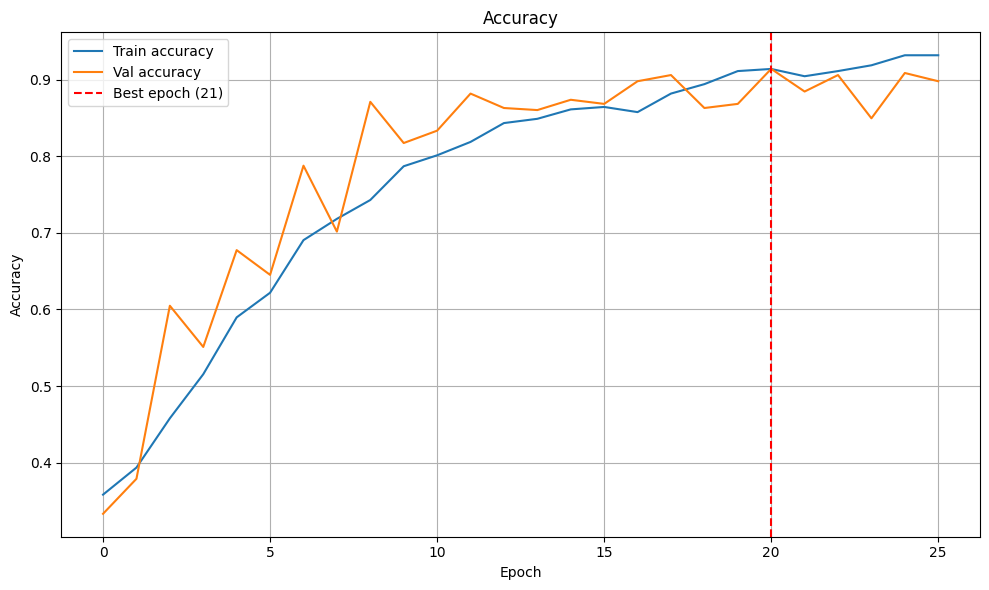

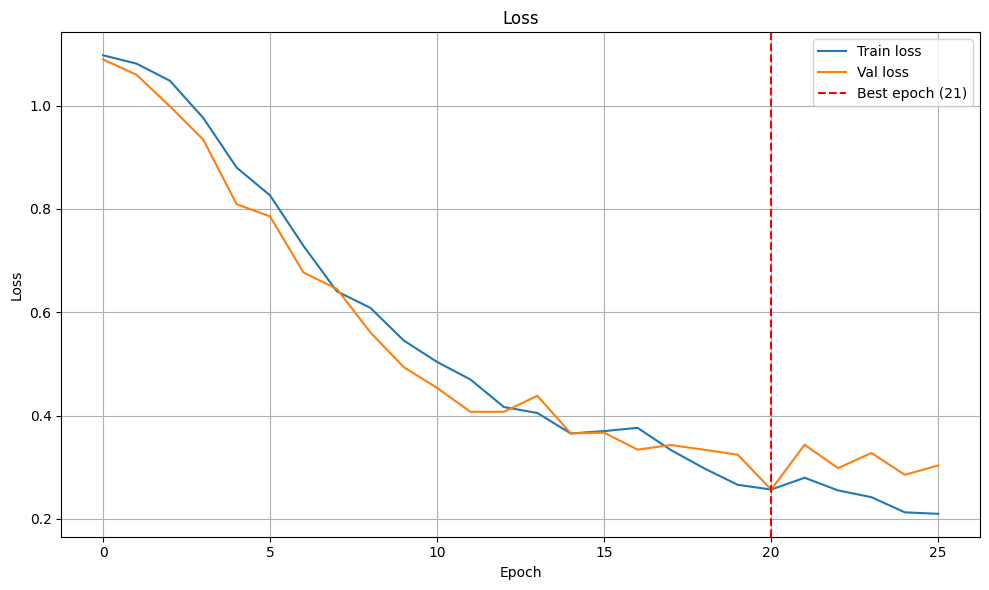

In [ ]:
#Probably not worth it, because the dataset is pretty limited and with little manual tuning I reached 95 % validation accuraccy
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_datasets as tfds
import keras_tuner as kt

# ── Load & preprocess ──────────────────────────────────────────────
IMG_SIZE = (64, 64)
BATCH    = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def plot_history(history, early_stopping):
    stopped_epoch = early_stopping.stopped_epoch
    best_epoch = stopped_epoch - early_stopping.patience if stopped_epoch > 0 else None

    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'],     label='Train accuracy')
    plt.plot(history.history['val_accuracy'], label='Val accuracy')
    if best_epoch:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['val_loss'], label='Val loss')
    if best_epoch:
        plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

ds = tfds.load('rock_paper_scissors', as_supervised=True)
train_ds = (ds['train']
            .map(preprocess)
            .shuffle(1000)
            .map(augment)
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))
test_ds  = (ds['test']
            .map(preprocess)
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))

# ── Build model with hyperparameters ──────────────────────────────
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(64, 64, 3)))

    model.add(layers.RandomFlip('horizontal'))
    model.add(layers.RandomFlip('vertical'))
    model.add(layers.RandomRotation(factor=0.20))
    model.add(layers.RandomContrast(factor=0.5))
    model.add(layers.RandomTranslation(height_factor=0.1, width_factor=0.1))

    # More conv block options
    for i in range(hp.Int('num_conv_blocks', min_value=1, max_value=5)):
        model.add(layers.Conv2D(
            filters=hp.Choice(f'filters_{i}', values=[16, 32, 64, 128, 256, 512]),
            kernel_size=hp.Choice('kernel_size', values=[3, 5]),  # also tune kernel size
            activation='relu',
            padding='same'
        ))
        model.add(layers.MaxPooling2D())

        # Optionally add dropout after each conv block
        if hp.Boolean(f'conv_dropout_{i}'):
            model.add(layers.Dropout(rate=0.25))

    model.add(layers.Flatten())

    # Multiple dense layers
    for j in range(hp.Int('num_dense_layers', min_value=1, max_value=3)):
        model.add(layers.Dense(
            units=hp.Choice(f'dense_units_{j}', values=[64, 128, 256, 512]),
            activation='relu'
        ))

    model.add(layers.Dropout(
        rate=hp.Float('dropout', min_value=0.2, max_value=0.7, step=0.05)
    ))
    model.add(layers.Dense(3, activation='softmax'))

    # Also tune optimizer
    optimizer_name = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Bayesian Optimization ──────────────────────────────────────────
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=40,
    num_initial_points=10,
    directory='kt_results',
    project_name='rps_bayes_v2'
)

tuner.search_space_summary()

# ── Callbacks ──────────────────────────────────────────────────────
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ── Search ─────────────────────────────────────────────────────────
tuner.search(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

# ── Results ────────────────────────────────────────────────────────
tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Best hyperparameters found:
  - Conv blocks:    {best_hps.get('num_conv_blocks')}
  - Filters block 0: {best_hps.get('filters_0')}
  - Dense units:    {best_hps.get('dense_units')}
  - Dropout:        {best_hps.get('dropout')}
  - Learning rate:  {best_hps.get('learning_rate')}
""")

# ── Train final model with best hyperparameters ────────────────────
best_model = tuner.hypermodel.build(best_hps)

early_stopping_final = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = best_model.fit(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping_final]
)

# ── Save ───────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
best_model.save('/content/drive/MyDrive/rps_best_model.keras')
best_model.save('/content/drive/MyDrive/rps_best_model.h5')
print("Model saved!")

# ── Plot ───────────────────────────────────────────────────────────
plot_history(history, early_stopping_final)